<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/EDA_univariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA on every column individually (univariate analysis)

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
df = pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')

In [213]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_builtup_area,builtup_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3,2,2,...,1081.0,NaN,650.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2,2,2,...,NaN,NaN,1103.0,1,1,0,0,0,0,38
2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,NaN,NaN,58141.0,0,0,0,0,0,1,15
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2,2,1,...,NaN,1000.0,585.0,0,0,0,0,0,1,49
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3,4,3+,...,1995.0,1615.0,1476.0,0,1,0,0,1,2,174


In [214]:
df.shape

(3803, 23)

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       3803 non-null   object 
 1   society             3802 non-null   object 
 2   sector              3803 non-null   object 
 3   price               3785 non-null   float64
 4   price_per_sqft      3785 non-null   float64
 5   area                3785 non-null   float64
 6   areaWithType        3803 non-null   object 
 7   bedRoom             3803 non-null   int64  
 8   bathroom            3803 non-null   int64  
 9   balcony             3803 non-null   object 
 10  floorNum            3784 non-null   float64
 11  facing              2698 non-null   object 
 12  agePossession       3803 non-null   object 
 13  super_builtup_area  1915 non-null   float64
 14  builtup_area        1733 non-null   float64
 15  carpet_area         1944 non-null   float64
 16  study 

In [216]:
print(df.duplicated().sum())

126


In [217]:
df.drop_duplicates(inplace=True)

## property type

<Axes: xlabel='property_type'>

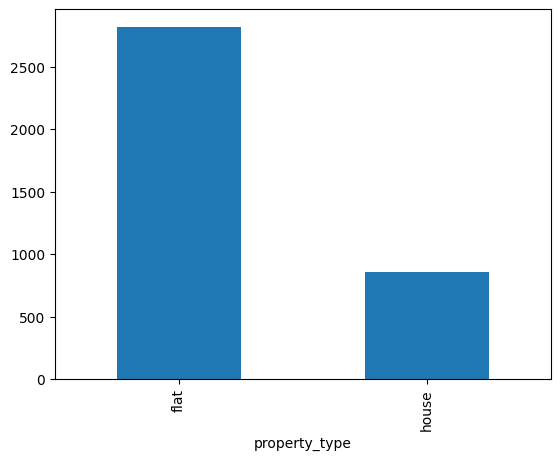

In [218]:
df['property_type'].value_counts().plot(kind='bar')

In [219]:
print(df['property_type'].isnull().sum())

0


Society

In [220]:
df['society'].head()

,society
0,signature global park 4
1,smart world gems
2,pyramid elite
3,breez global hill view
4,bestech park view sanskruti


In [221]:
print(df['society'].isnull().sum())

1


In [222]:
df['society'].shape[0]

3677

In [223]:
print(df['society'].value_counts().head())

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
Name: count, dtype: int64


In [224]:
df['society'].value_counts().shape

# 676 different categories are there

(676,)

In [225]:
# out of 3677 , 486 are independent societies (nan)

In [226]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)

,proportion
society,
tulip violet,0.023511
ss the leaf,0.046395
shapoorji pallonji joyville gurugram,0.059561
dlf new town heights,0.072727
signature global park,0.083699
...,...
ramsons kshitij,0.490282
ats kocoon,0.494357
ansal heights 86,0.498433


In [227]:
df['society'].head(5)

,society
0,signature global park 4
1,smart world gems
2,pyramid elite
3,breez global hill view
4,bestech park view sanskruti


In [228]:
# creating frequency bins to understand how many number of flats are in a society
society_counts = df['society'].value_counts()
frequency_bins ={
    "Very High (>100)":(society_counts>100).sum(),
    "High (50-100)":((society_counts>=50) & (society_counts<=100)).sum(),
    "Average (10-49)":((society_counts>=10) & (society_counts<50)).sum(),
    "Low(2-9)":((society_counts>1)&(society_counts<10)).sum(),
    "Very Low":(society_counts==1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low(2-9)': np.int64(273),
 'Very Low': np.int64(308)}

<Axes: xlabel='society'>

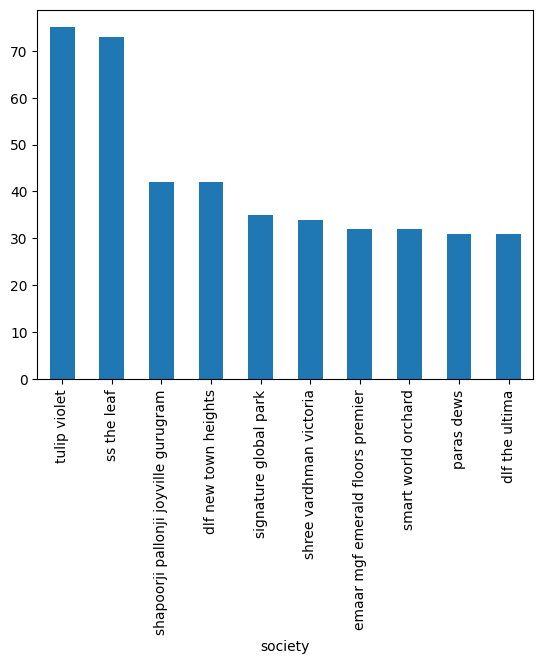

In [229]:
# plotting the top 10 societies
df[df['society']!='independent']['society'].value_counts().head(10).plot(kind='bar')

In [230]:
df['society'].isnull().sum()

np.int64(1)

## sector

In [231]:
df['sector'].head()

,sector
0,sector 36
1,sector 89
2,sector 86
3,sohna road
4,sector 92


In [232]:
df['sector'].isnull().sum()

np.int64(0)

In [233]:
df['sector'].shape

(3677,)

In [234]:
df['sector'].value_counts(normalize=True).cumsum()

,proportion
sector,
sohna road,0.041882
sector 85,0.071254
sector 102,0.100354
sector 92,0.127550
sector 69,0.152842
...,...
sector 17b,0.997280
sector 73,0.998096
sector 88b,0.998912


<Axes: xlabel='sector'>

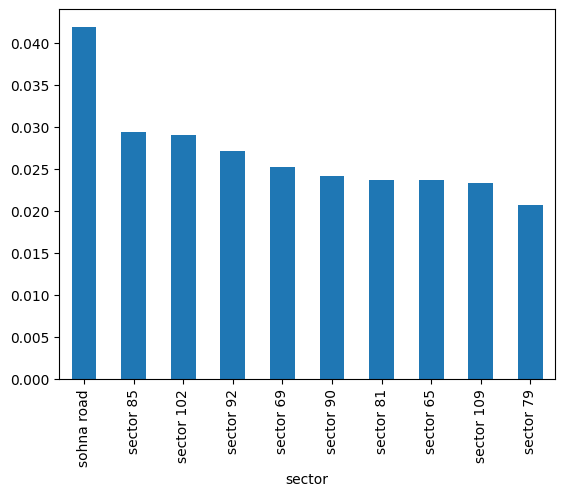

In [235]:
df['sector'].value_counts(normalize=True).head(10).plot(kind='bar')

In [236]:
# make bins

sector_counts = df['sector'].value_counts()

sector_freq_bins= {
    "very high frequency(>100)" : (sector_counts>100).sum(),
    "high frequency(50-100)": ((sector_counts>=50) & (sector_counts<=100)).sum(),
    "Average(10-49)":((sector_counts>=10)&(sector_counts<50)).sum(),
    "Low(2-9)":((sector_counts>1) & (sector_counts<10)).sum(),
    "very low (1)":(sector_counts==1).sum()
}
sector_freq_bins

{'very high frequency(>100)': np.int64(3),
 'high frequency(50-100)': np.int64(25),
 'Average(10-49)': np.int64(63),
 'Low(2-9)': np.int64(21),
 'very low (1)': np.int64(1)}

## Price

In [237]:
df['price'].isnull().sum()

np.int64(17)

In [238]:
df['price'].duplicated().sum()

np.int64(3203)

In [239]:
print(df['price'].value_counts())

price
1.25    80
1.50    64
1.20    64
0.90    63
1.10    62
        ..
7.45     1
2.96     1
1.84     1
7.30     1
0.57     1
Name: count, Length: 473, dtype: int64


In [240]:
df['price'].value_counts().shape

(473,)

In [241]:
df['price'].describe()

,price
count,3660.000000
mean,2.533664
std,2.980623
min,0.070000
25%,0.950000
50%,1.520000
75%,2.750000
max,31.500000


<Axes: xlabel='price', ylabel='Density'>

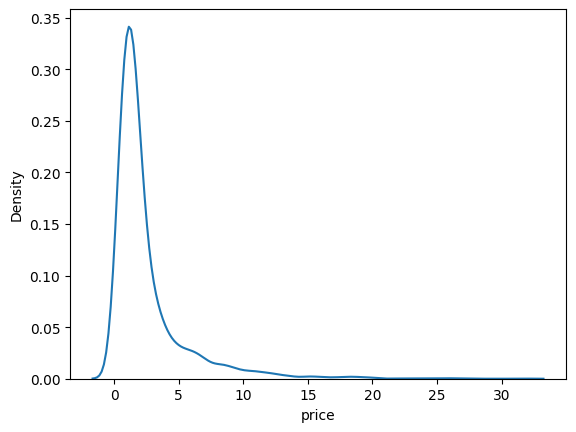

In [242]:
sns.kdeplot(df['price'])

<Axes: xlabel='price', ylabel='Count'>

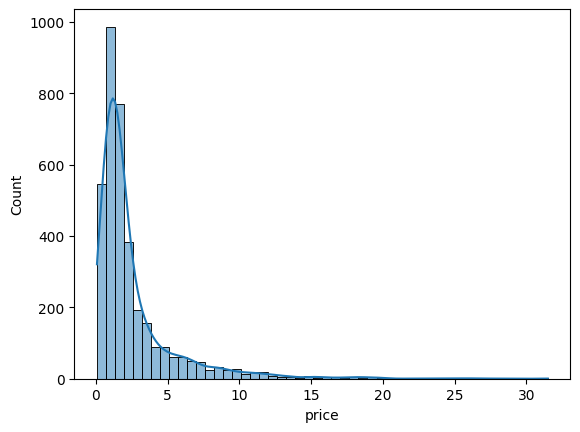

In [243]:
sns.histplot(df['price'],kde=True,bins=50)

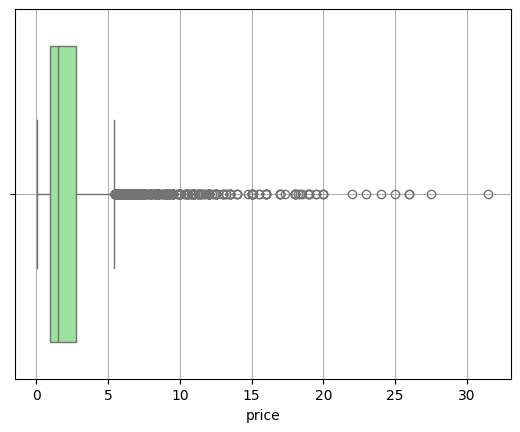

In [244]:
sns.boxplot(x=df['price'] , color ='lightgreen')
plt.grid()

In [245]:
print("the skewness of data is : ",df['price'].skew())        # a measure to tell how the data is not normally distributed . this is a right skewed data
print("the kurtosis of the data is ",df['price'].kurt())      # kurtosis tells the thickness of the tail , 14.93 indicates that more outliers exists than normal distribution

the skewness of data is :  3.2791704733134623
the kurtosis of the data is  14.933372629214258


In [246]:
# outliers

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3-q1
lower_bound = q1- 1.5*iqr
upper_bound = q3+ 1.5*iqr

print(lower_bound , upper_bound)

-1.7500000000000002 5.45


In [247]:
outliers = df[(df['price']<lower_bound) |(df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [248]:
outliers['price'].describe()

,price
count,425.000000
mean,9.235624
std,4.065259
min,5.460000
25%,6.460000
50%,8.000000
75%,10.750000
max,31.500000


<Axes: xlabel='price'>

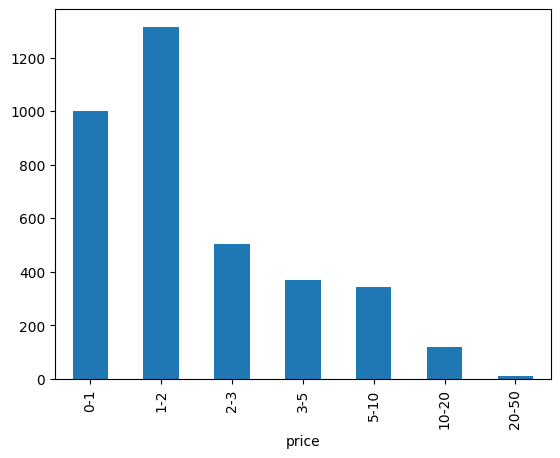

In [249]:
bins = [0,1,2,3,5,10,20,50]
bin_labels = ["0-1","1-2","2-3","3-5","5-10","10-20","20-50"]
pd.cut(df['price'],bins=bins , labels = bin_labels , right = False).value_counts().sort_index().plot(kind='bar')

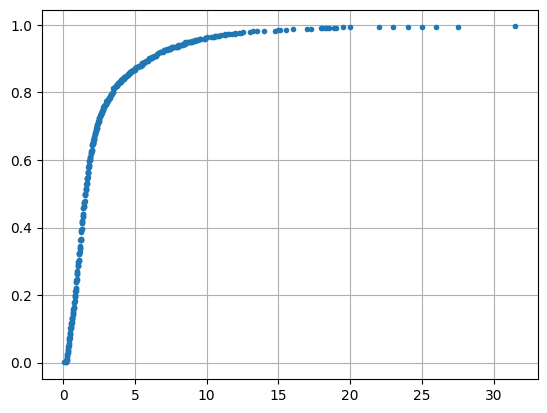

In [250]:
# ecdf plot to understand the cumulative distribution

ecdf = df['price'].value_counts().sort_index().cumsum() / df['price'].shape[0]
plt.plot(ecdf.index,ecdf,marker='.',linestyle='none')
plt.grid()

In [251]:
# log transforming the price distribution as it is right skewed

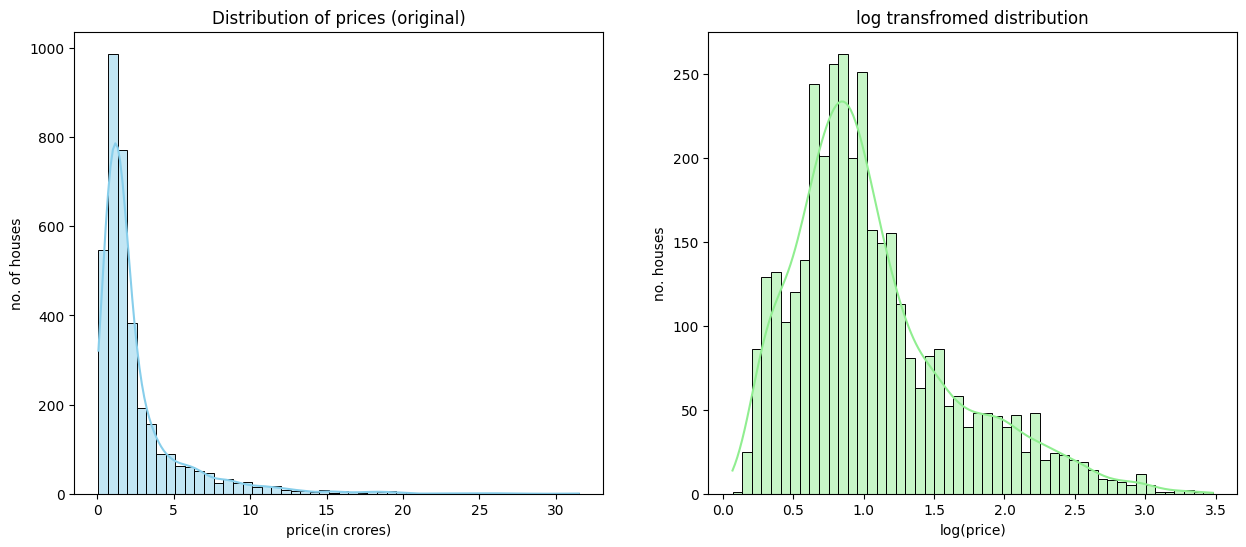

In [252]:
plt.figure(figsize=(15,6))

# original plot
plt.subplot(1,2,1)
sns.histplot(df['price'],kde=True,bins=50,color='skyblue')
plt.title('Distribution of prices (original)')
plt.xlabel('price(in crores)')
plt.ylabel('no. of houses')

# plot with log transformation
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']),kde=True,bins=50 , color ='lightgreen')      # log1p is used instead of log to avoid negative values on the x axis
plt.title('log transfromed distribution')                                       # log1p takes  log(1+x) than log(x) , thus negatve values are avoided
plt.xlabel('log(price)')
plt.ylabel('no. houses')

plt.show()

In [253]:
# the data is now closer to the normal distribution than the original distribution

Text(0, 0.5, 'no. of houses')

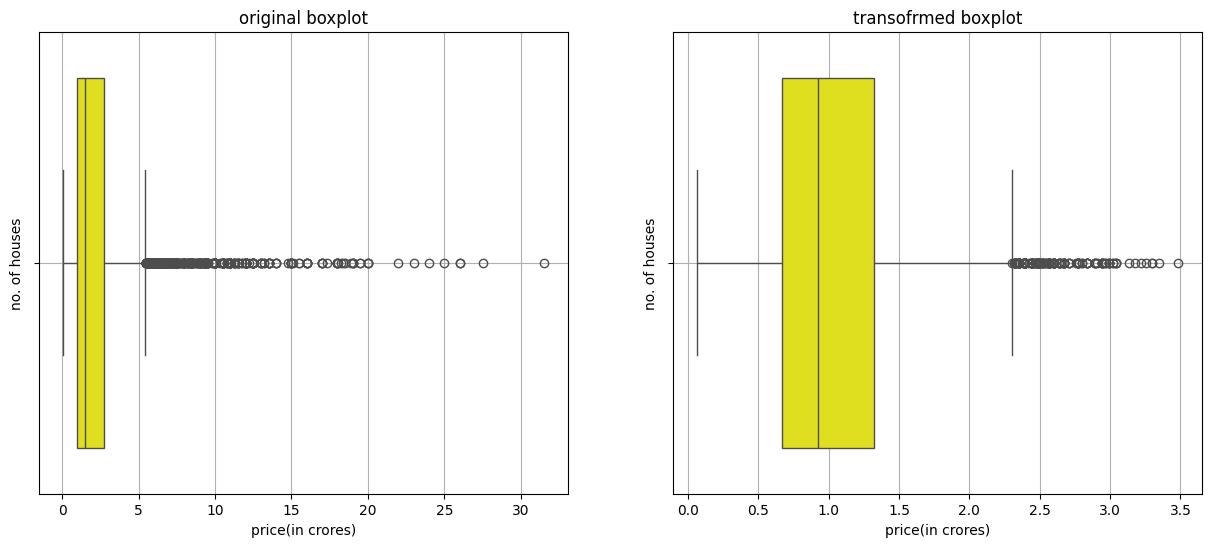

In [254]:
plt.figure(figsize=(15,6))

# original box plot

plt.subplot(1,2,1)
sns.boxplot(x=df['price'] , color ='yellow')
plt.grid()
plt.title('original boxplot')
plt.xlabel('price(in crores)')
plt.ylabel('no. of houses')
# trnsformed boxplot :

plt.subplot(1,2,2)
sns.boxplot(x=np.log1p(df['price']) , color ='yellow')
plt.grid()
plt.title('transofrmed boxplot')
plt.xlabel('price(in crores)')
plt.ylabel('no. of houses')

## price per sqft

In [255]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [256]:
df['price_per_sqft'].value_counts().shape

(2651,)

In [257]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3660.000000
mean,13892.668306
std,23210.067190
min,4.000000
25%,6817.250000
50%,9020.000000
75%,13880.500000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

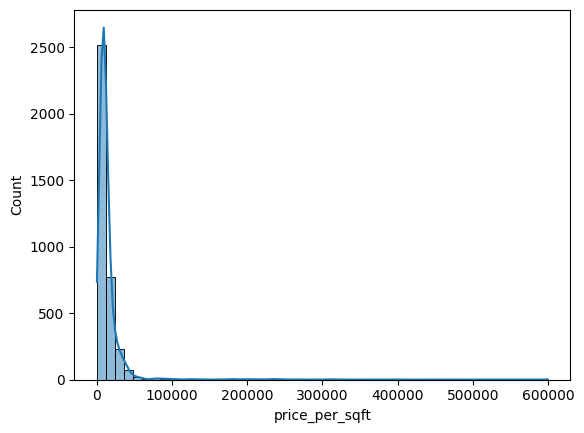

In [258]:
sns.histplot(df['price_per_sqft'] , kde =True , bins=50)

<Axes: xlabel='price_per_sqft'>

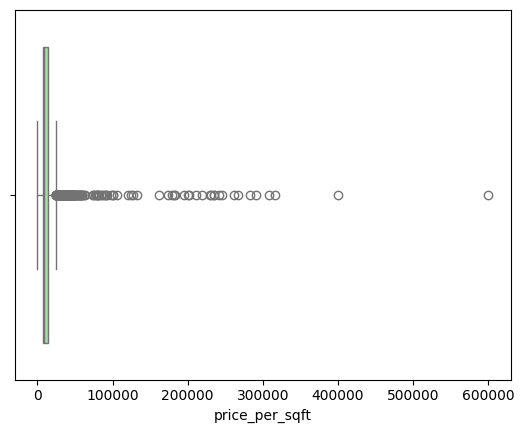

In [259]:
sns.boxplot(x=df['price_per_sqft'],color='lightgreen')

## bedroom

In [260]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

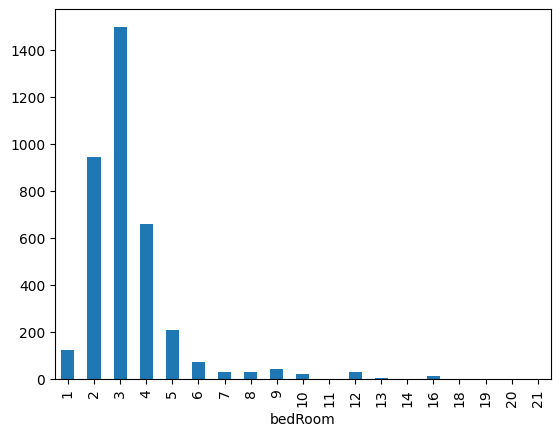

In [261]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

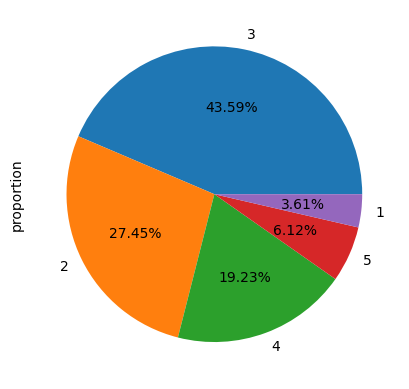

In [262]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

## bathrooms


In [263]:
df['bathroom'].isnull().sum()

np.int64(0)

In [264]:
df['bathroom'].value_counts()

,count
bathroom,
3,1077
2,1047
4,820
5,294
1,156
6,117
9,41
7,40
8,25


<Axes: xlabel='bathroom'>

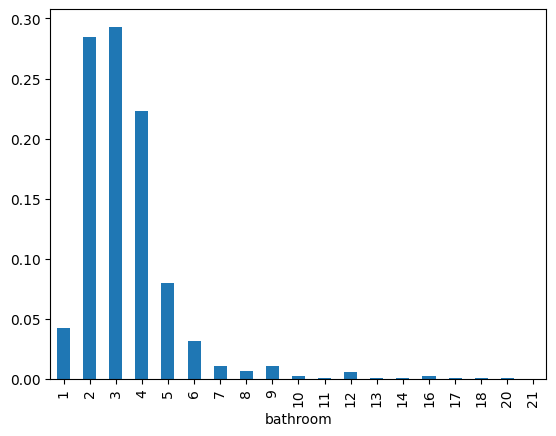

In [265]:
df['bathroom'].value_counts(normalize=True).sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

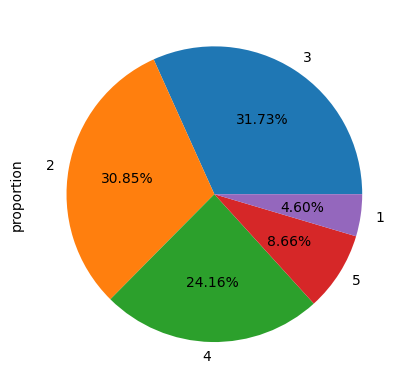

In [266]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

##balconies

In [267]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

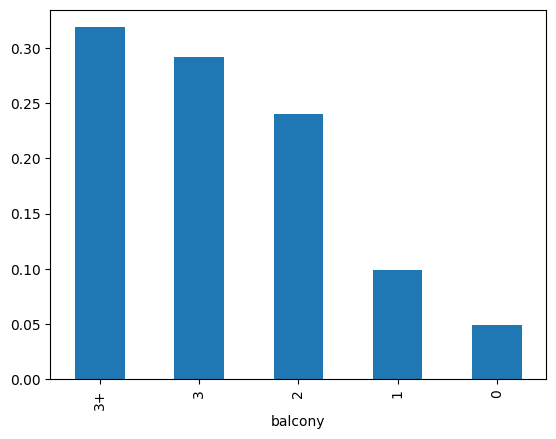

In [268]:
df['balcony'].value_counts(normalize=True).plot(kind='bar')

<Axes: ylabel='proportion'>

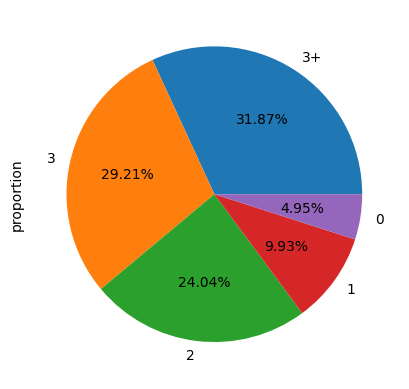

In [269]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

## floor num

In [270]:
df['floorNum'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: floorNum
Non-Null Count  Dtype  
--------------  -----  
3658 non-null   float64
dtypes: float64(1)
memory usage: 57.5 KB


In [271]:
df['floorNum'].describe()

,floorNum
count,3658.000000
mean,6.798250
std,6.012454
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


In [272]:
df['floorNum'].isnull().sum()

np.int64(19)

In [273]:
df['floorNum'].value_counts(normalize=True).cumsum()

,proportion
floorNum,
3.0,0.136140
2.0,0.270913
1.0,0.366867
4.0,0.453253
8.0,0.506561
6.0,0.556588
10.0,0.605522
7.0,0.653636
5.0,0.699836


<Axes: xlabel='floorNum'>

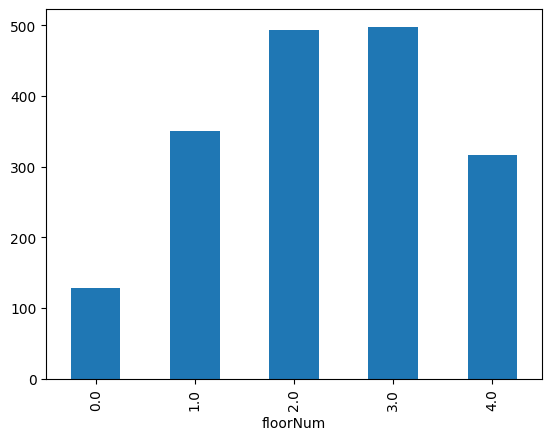

In [274]:
df['floorNum'].value_counts().sort_index().head().plot(kind='bar')

<Axes: xlabel='floorNum', ylabel='Count'>

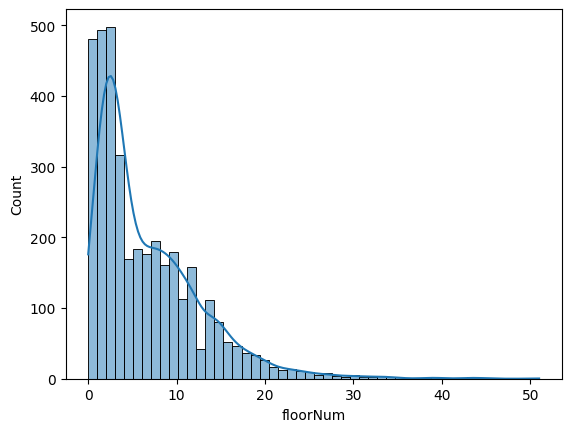

In [275]:
sns.histplot(df['floorNum'],kde=True)

<Axes: xlabel='floorNum'>

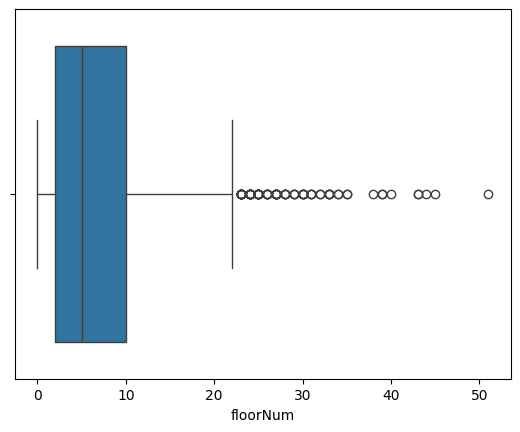

In [276]:
sns.boxplot(x=df['floorNum'])

## Facing

In [277]:
df['facing'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: facing
Non-Null Count  Dtype 
--------------  ----- 
2632 non-null   object
dtypes: object(1)
memory usage: 57.5+ KB


In [278]:
df['facing'].isnull().sum()

np.int64(1045)

In [279]:
df['facing'].value_counts()

,count
facing,
North-East,623
East,623
North,387
West,249
South,231
North-West,193
South-East,173
South-West,153


<Axes: ylabel='proportion'>

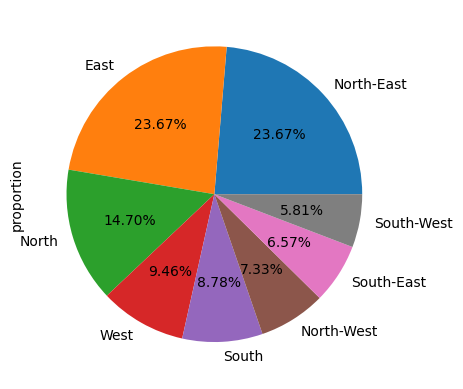

In [280]:
df['facing'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')

# agePossesion

In [281]:
df['agePossession'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: agePossession
Non-Null Count  Dtype 
--------------  ----- 
3677 non-null   object
dtypes: object(1)
memory usage: 57.5+ KB


In [282]:
df['agePossession'].isnull().sum()

np.int64(0)

In [283]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1646
New Property,593
Moderately Old,563
undefined,306
Old Property,303
Under Construction,266


# areas

superbuiltup area : builtup area + lobby (common area aaround the flat)

builtup area : area of the house(floor) + balcony + thickness of the walls in the house

carpet area : builtup area - area of the balcony and the thickness of the walls


best metric = built up area

In [284]:
# super built up area

In [285]:
df['super_builtup_area'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: super_builtup_area
Non-Null Count  Dtype  
--------------  -----  
1875 non-null   float64
dtypes: float64(1)
memory usage: 57.5 KB


In [286]:
df['super_builtup_area'].describe()

,super_builtup_area
count,1875.000000
mean,1925.237627
std,764.172177
min,89.000000
25%,1479.500000
50%,1828.000000
75%,2215.000000
max,10000.000000


In [287]:
df['super_builtup_area'].isnull().sum()

np.int64(1802)

In [288]:
df['super_builtup_area'].value_counts().shape[0]

593

<Axes: xlabel='super_builtup_area', ylabel='Count'>

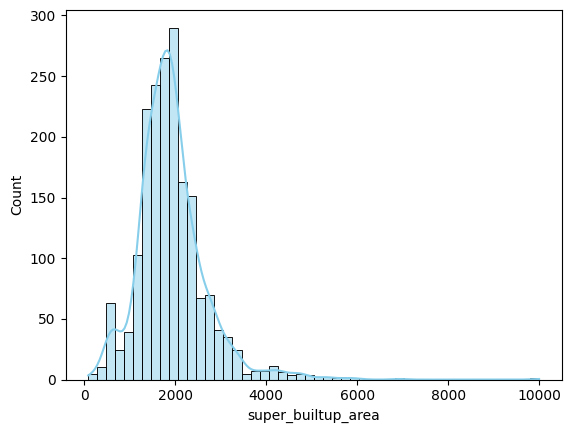

In [289]:
sns.histplot(df['super_builtup_area'].dropna(),bins=50,color='skyblue',kde=True)

<Axes: xlabel='super_builtup_area'>

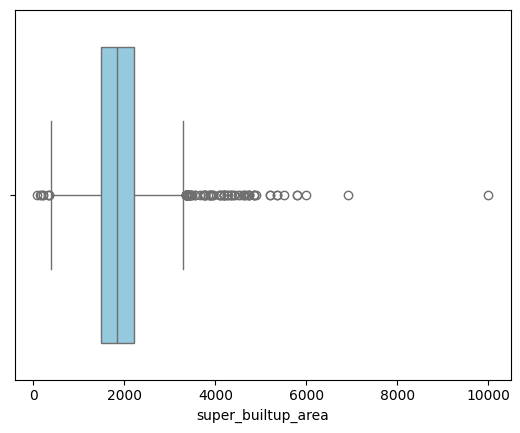

In [290]:
sns.boxplot(x=df['super_builtup_area'],color='skyblue')

# builtup area

In [291]:
df['builtup_area'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: builtup_area
Non-Null Count  Dtype  
--------------  -----  
1690 non-null   float64
dtypes: float64(1)
memory usage: 57.5 KB


In [292]:
df['builtup_area'].isnull().sum()

np.int64(1987)

In [293]:
df['builtup_area'].describe()

,builtup_area
count,1690.000000
mean,2605.373828
std,18778.325737
min,30.000000
25%,1150.000000
50%,1700.000000
75%,2430.000000
max,737147.000000


<Axes: xlabel='builtup_area'>

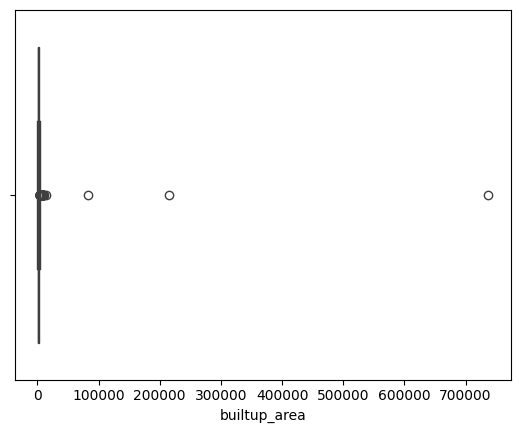

In [294]:
sns.boxplot(x = df['builtup_area'])

In [295]:
# the extreme data point is a data error and should not exist

# carpet area

In [296]:
df['carpet_area'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: carpet_area
Non-Null Count  Dtype  
--------------  -----  
1872 non-null   float64
dtypes: float64(1)
memory usage: 57.5 KB


In [297]:
df['carpet_area'].isnull().sum()

np.int64(1805)

In [298]:
df['carpet_area'].describe()

,carpet_area
count,1872.000000
mean,2529.179507
std,22799.836449
min,15.000000
25%,843.000000
50%,1300.000000
75%,1790.000000
max,607936.000000


<Axes: xlabel='carpet_area'>

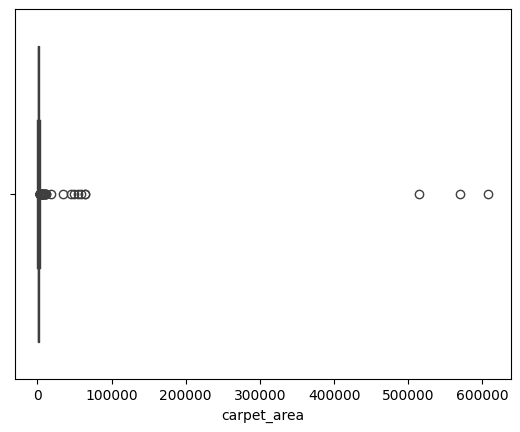

In [299]:
sns.boxplot(x = df['carpet_area'])

In [300]:
# the area section has outliers and missing values . handling them properly is required

# additional rooms

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_type       3677 non-null   object 
 1   society             3676 non-null   object 
 2   sector              3677 non-null   object 
 3   price               3660 non-null   float64
 4   price_per_sqft      3660 non-null   float64
 5   area                3660 non-null   float64
 6   areaWithType        3677 non-null   object 
 7   bedRoom             3677 non-null   int64  
 8   bathroom            3677 non-null   int64  
 9   balcony             3677 non-null   object 
 10  floorNum            3658 non-null   float64
 11  facing              2632 non-null   object 
 12  agePossession       3677 non-null   object 
 13  super_builtup_area  1875 non-null   float64
 14  builtup_area        1690 non-null   float64
 15  carpet_area         1872 non-null   float64
 16  study room 

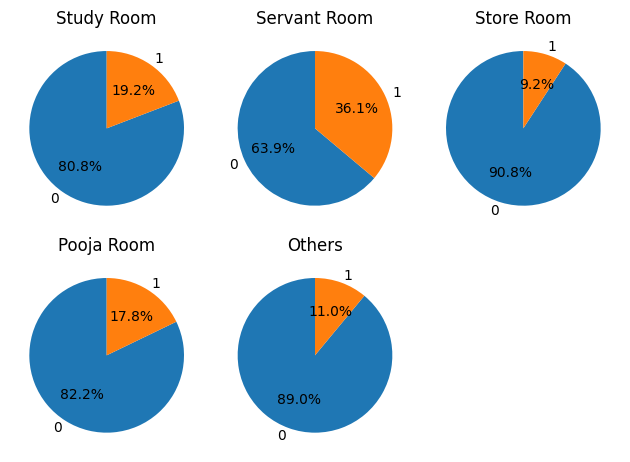

In [302]:
for idx , room in enumerate(['study room','servant room','store room' , 'pooja room' ,'others'],1):
  ax = plt.subplot(2,3,idx)
  df[room].value_counts().plot.pie(autopct='%1.1f%%',startangle = 90 ,ax=ax)
  plt.title(f'{room.title()}')
  plt.ylabel('')

plt.tight_layout()
plt.show()


# furnishing

In [303]:
df['furnishing_type'].isnull().sum()

np.int64(0)

In [304]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
1,1491
0,1148
2,1038


<Axes: ylabel='count'>

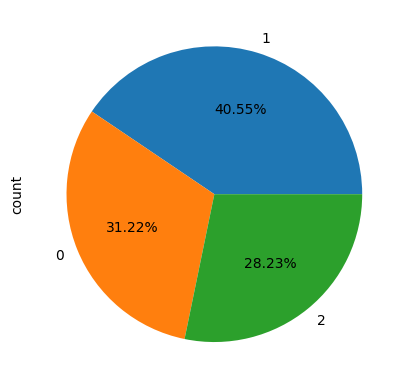

In [305]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

#Luxury Score

In [306]:
df['luxury_score'].info()

<class 'pandas.core.series.Series'>
Index: 3677 entries, 0 to 3802
Series name: luxury_score
Non-Null Count  Dtype
--------------  -----
3677 non-null   int64
dtypes: int64(1)
memory usage: 57.5 KB


In [307]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [308]:
df['luxury_score'].describe()

,luxury_score
count,3677.000000
mean,71.512918
std,53.059082
min,0.000000
25%,31.000000
50%,59.000000
75%,110.000000
max,174.000000


<Axes: xlabel='luxury_score', ylabel='Count'>

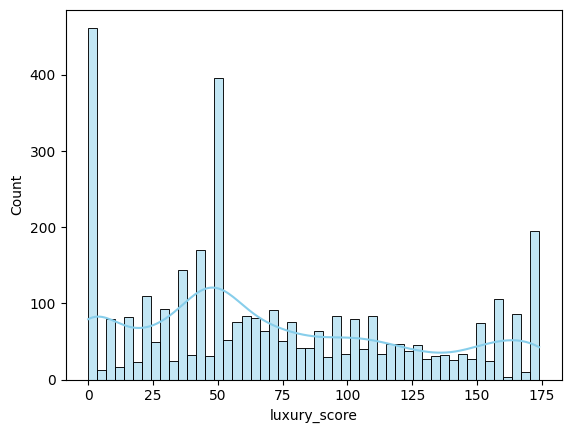

In [309]:
sns.histplot(df['luxury_score'],bins=50,color='skyblue',kde=True)

<Axes: xlabel='luxury_score'>

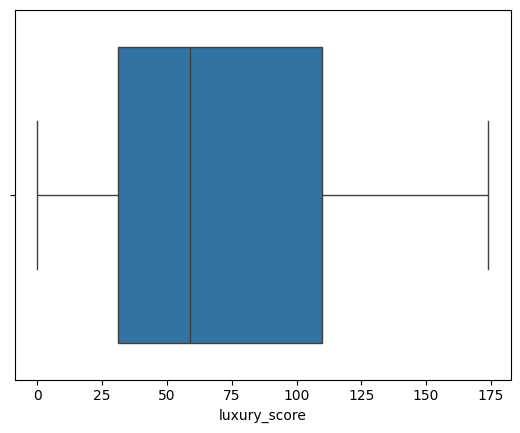

In [310]:
sns.boxplot(x=df['luxury_score'])